In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [37]:
base_cat = cv2.imread(".\\base_cat.png")

gray_cat = cv2.cvtColor(base_cat, cv2.COLOR_BGR2GRAY)
U, S, Vt = np.linalg.svd(gray_cat, full_matrices=False)
S_diag = np.diag(S)

print("Original image shape:", gray_cat.shape)
print(f'U shape: {U.shape},  S shape: {S.shape},  V^T shape: {Vt.shape}')

Original image shape: (185, 280)
U shape: (185, 185),  S shape: (185,),  V^T shape: (185, 280)


In [34]:
r_options = [1, 2, 5, 10, 50, 100]

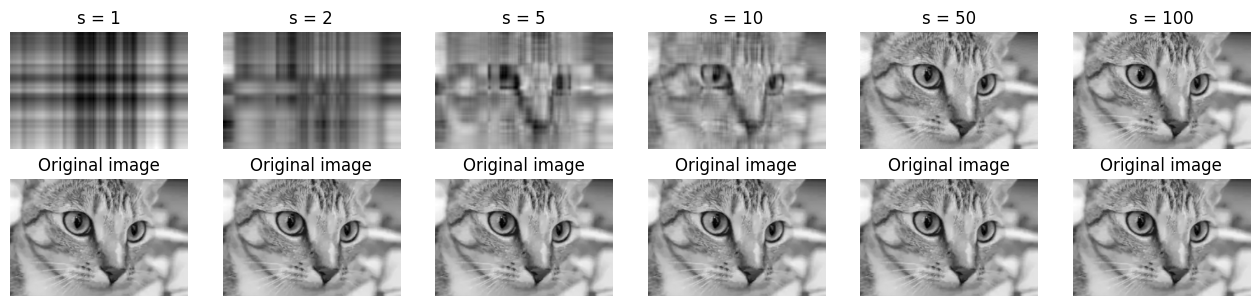

In [38]:
fig, ax = plt.subplots(2, len(r_options), figsize=(16, 3.5))
curr_fig = 0

for r in r_options:
    cat_approx = U[:, :r] @ S_diag[:r, :r] @ Vt[:r, :]
    ax[0][curr_fig].imshow(cat_approx, cmap='gray')
    ax[0][curr_fig].set_title("s = " + str(r))
    ax[0][curr_fig].axis('off')
    ax[1][curr_fig].set_title("Original image")
    ax[1][curr_fig].imshow(gray_cat, cmap='gray')
    ax[1, curr_fig].axis('off')
    curr_fig += 1
plt.show()

In [ ]:
var_explained = np.round(S**2/np.sum(S**2), decimals=3)
print(f'Variance Explained by Top-20 singular values (in %):\n{var_explained[0:20]*100}')

Variance Explained by Top-20 singular values (in %):
[94.3  1.6  1.1  0.5  0.5  0.3  0.3  0.2  0.2  0.2  0.1  0.1  0.1  0.1
  0.1  0.1  0.   0.   0.   0. ]
